# Árboles de Decisión para Regresión

_Intuición, partición recursiva y comparación con la regresión lineal_

**Módulo 1 — Aprendizaje Supervisado** | DSRP Machine Learning Engineering  
**Profesor:** Miguel Arquez

![Aprendizaje Supervisado](assets/header.png)

## 1. Intuición — preguntas tipo "sí/no"

Un árbol de decisión es básicamente una secuencia de **preguntas binarias** sobre los predictores. En cada nodo se pregunta algo como _"¿`GrLivArea` ≤ 1500?"_ y según la respuesta se baja por la rama izquierda o derecha hasta llegar a una **hoja** que contiene la predicción (la media de $y$ entre las observaciones que cayeron ahí). Más adelante visualizamos un árbol real entrenado sobre House Prices.

## 2. ¿Qué hace el árbol con el espacio de los datos?

Cada split parte el espacio de los predictores en **regiones rectangulares**. En cada región el árbol predice un valor constante (la media de $y$). La gráfica siguiente lo muestra sobre datos sintéticos en 2D.

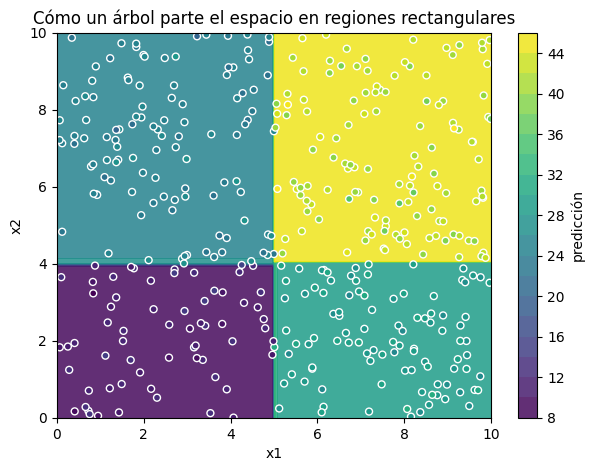

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

rng = np.random.default_rng(0)
n = 400
X = rng.uniform(0, 10, size=(n, 2))
y = (
    np.where(X[:, 0] < 5, 10, 30)
    + np.where(X[:, 1] < 4, 0, 15)
    + rng.normal(0, 2, n)
)

tree = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X, y)

xx, yy = np.meshgrid(np.linspace(0, 10, 200), np.linspace(0, 10, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = tree.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.contourf(xx, yy, zz, levels=20, cmap='viridis', alpha=0.85)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='white', s=25)
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Cómo un árbol parte el espacio en regiones rectangulares')
plt.colorbar(im, ax=ax, label='predicción')
plt.show()

## 3. ¿Cómo elige cada corte?

En cada nodo el árbol prueba todas las variables y todos los puntos de corte y se queda con el split que **deja los grupos más "compactos"** (menos variabilidad interna respecto a la media). Para regresión, eso significa minimizar la suma de cuadrados de los residuos en los dos hijos. La idea es:

> _"Quiero que las casas dentro de cada hoja se parezcan en precio."_

El proceso se repite recursivamente hasta cumplir un criterio de parada (profundidad máxima, mínimo de muestras por hoja, etc.) y luego se suele aplicar **poda** (`ccp_alpha`) para reducir overfitting.

## 4. Árbol vs regresión lineal

| | Lineal | Árbol |
|---|---|---|
| Relaciones no lineales | requieren transformaciones | las captura naturalmente |
| Interacciones entre variables | hay que codificarlas | implícitas en los splits |
| Escala de los features | sensible | indiferente |
| Interpretabilidad | coeficientes y p-valores | reglas if/else legibles |
| Forma de la predicción | suave | escalonada |
| Riesgo de overfitting | bajo–medio | alto sin poda |
| Extrapolación | sí | no — predice constantes fuera del rango visto |

## 5. Hiperparámetros clave (`DecisionTreeRegressor`)

- `max_depth` — profundidad máxima.
- `min_samples_split` — mínimo de muestras para considerar un split.
- `min_samples_leaf` — mínimo de muestras por hoja.
- `ccp_alpha` — parámetro de poda (cost-complexity pruning).

## 6. Caso práctico — House Prices

Mismo dataset que el notebook 02: cada fila es una vivienda en Ames, Iowa, y queremos predecir `SalePrice`. Usamos solo `housing_train.csv` (el `housing_test.csv` de la competencia no trae la etiqueta) y lo partimos con `train_test_split`.

In [2]:
from pathlib import Path
import pandas as pd

DATA = Path('../data/housing_train.csv')
if not DATA.exists():
    raise FileNotFoundError(
        f'No se encontró {DATA}. Descarga housing_train.csv desde '
        'https://www.kaggle.com/c/house-prices-advanced-regression-techniques '
        'y colócalo en data/ (ver README.md).'
    )

df = pd.read_csv(DATA)
print('Shape:', df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
len(X_tr)

1168

In [40]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'GarageCars',
            'TotalBsmtSF', 'FullBath']
data = df[features + ['SalePrice']].dropna()
X = data[features]
y = data['SalePrice']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

tree = DecisionTreeRegressor(max_depth=3, min_samples_split=10, random_state=42).fit(X_tr, y_tr)
lr   = LinearRegression().fit(X_tr, y_tr)

def reporte(nombre, y_true, y_pred):
    print(f'--- {nombre} ---')
    print(f'  MAE  = {mean_absolute_error(y_true, y_pred):,.0f}')
    print(f'  RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}')
    print(f'  R²   = {r2_score(y_true, y_pred):.3f}')

reporte('Decision Tree (depth=3)', y_te, tree.predict(X_te))
reporte('Regresión lineal',         y_te, lr.predict(X_te))

--- Decision Tree (depth=3) ---
  MAE  = 30,559
  RMSE = 44,135
  R²   = 0.746
--- Regresión lineal ---
  MAE  = 25,320
  RMSE = 39,711
  R²   = 0.794


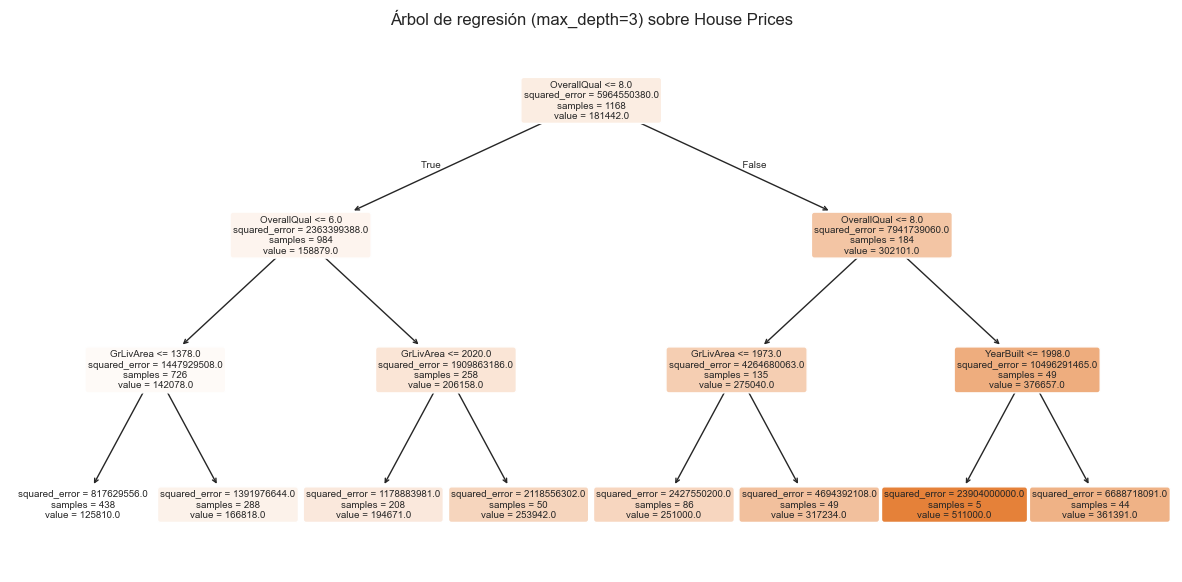

In [41]:
fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    tree, feature_names=features, filled=True,
    rounded=True, precision=0, ax=ax,
)
ax.set_title('Árbol de regresión (max_depth=3) sobre House Prices')
plt.show()

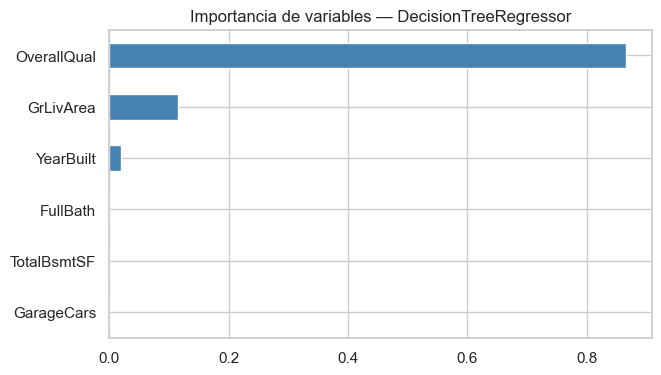

In [42]:
imp = pd.Series(tree.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(ax=ax, color='steelblue')
ax.set_title('Importancia de variables — DecisionTreeRegressor')
plt.show()

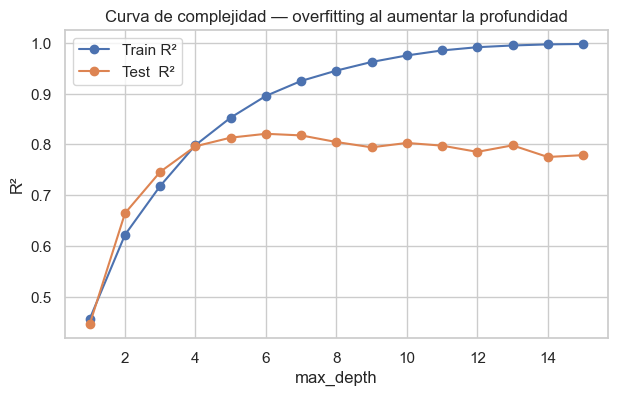

In [43]:
# --- ¿Cuánto debería medir el árbol? Curva de complejidad ---
depths = range(1, 16)
tr_scores, te_scores = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_tr, y_tr)
    tr_scores.append(r2_score(y_tr, m.predict(X_tr)))
    te_scores.append(r2_score(y_te, m.predict(X_te)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, tr_scores, marker='o', label='Train R²')
ax.plot(depths, te_scores, marker='o', label='Test  R²')
ax.set_xlabel('max_depth'); ax.set_ylabel('R²')
ax.set_title('Curva de complejidad — overfitting al aumentar la profundidad')
ax.legend(); plt.show()

## 7. Referencias

- Breiman, Friedman, Olshen & Stone (1984). *Classification and Regression Trees*.
- ISLR cap. 8: *Tree-Based Methods*.
- scikit-learn user guide: https://scikit-learn.org/stable/modules/tree.html
- Dataset: https://www.kaggle.com/c/house-prices-advanced-regression-techniques

## Predicción sobre datos nuevos — uso del modelo en producción

Una vez que el modelo está validado en el conjunto de test, queremos usarlo para predecir sobre datos que **no hemos visto**. En la práctica seguimos tres pasos:

1. **Reentrenar con todos los datos disponibles.** Ya hicimos la validación con la partición train/test; ahora aprovechamos el 100% de la información para que el modelo final tenga la mejor estimación posible de los parámetros.
2. **Aplicar exactamente las mismas transformaciones** que durante el entrenamiento (mismas columnas, mismo encoding, misma escala) — un error muy común en producción es desalinear el preprocesamiento.
3. **Persistir el modelo** con `joblib` (o `pickle`) para reutilizarlo sin reentrenar.

In [44]:
import joblib

modelo_final = DecisionTreeRegressor(max_depth=4, random_state=42).fit(
    data[features], data['SalePrice']
)
joblib.dump(modelo_final, 'modelo_house_tree.pkl')
print('Modelo guardado:', 'modelo_house_tree.pkl')

Modelo guardado: modelo_house_tree.pkl


### Inferencia individual — una vivienda hipotética

In [45]:
nueva_casa = pd.DataFrame([{
    'GrLivArea':    2000,
    'OverallQual':  5.0,
    'YearBuilt':    2010,
    'GarageCars':   2,
    'TotalBsmtSF':  900,
    'FullBath':     3,
}])

precio = modelo_final.predict(nueva_casa)[0]
print(f'Precio estimado: ${precio:,.0f} USD')

Precio estimado: $175,546 USD


### Ventaja del árbol: ¿por qué predijo eso?

A diferencia de un modelo lineal, podemos preguntarle al árbol **en qué hoja cayó** la observación y qué reglas se aplicaron. Esto es muy útil para explicar una decisión a un usuario de negocio o a un regulador.

In [47]:
from sklearn.tree import export_text

hoja = modelo_final.apply(nueva_casa)[0]
print(f'La vivienda cayó en la hoja #{hoja}')
print(f'Predicción de esa hoja: ${precio:,.0f}\n')

print('Reglas del árbol (texto):')
print(export_text(modelo_final, feature_names=list(features)))

La vivienda cayó en la hoja #8
Predicción de esa hoja: $175,546

Reglas del árbol (texto):
|--- OverallQual <= 7.50
|   |--- OverallQual <= 6.50
|   |   |--- GrLivArea <= 1378.50
|   |   |   |--- TotalBsmtSF <= 1007.50
|   |   |   |   |--- value: [113919.92]
|   |   |   |--- TotalBsmtSF >  1007.50
|   |   |   |   |--- value: [146883.50]
|   |   |--- GrLivArea >  1378.50
|   |   |   |--- GarageCars <= 1.50
|   |   |   |   |--- value: [140816.30]
|   |   |   |--- GarageCars >  1.50
|   |   |   |   |--- value: [175545.56]
|   |--- OverallQual >  6.50
|   |   |--- GrLivArea <= 1941.00
|   |   |   |--- TotalBsmtSF <= 1469.00
|   |   |   |   |--- value: [185459.61]
|   |   |   |--- TotalBsmtSF >  1469.00
|   |   |   |   |--- value: [236635.54]
|   |   |--- GrLivArea >  1941.00
|   |   |   |--- TotalBsmtSF <= 1191.00
|   |   |   |   |--- value: [232135.00]
|   |   |   |--- TotalBsmtSF >  1191.00
|   |   |   |   |--- value: [273027.87]
|--- OverallQual >  7.50
|   |--- OverallQual <= 8.50
|   

### Inferencia en lote sobre el `housing_test.csv` de Kaggle

In [48]:
test_path = Path('../data/housing_test.csv')
if test_path.exists():
    test_df = pd.read_csv(test_path)
    X_new = test_df[features].fillna(test_df[features].median(numeric_only=True))
    test_df['SalePrice_pred'] = modelo_final.predict(X_new)
    display(test_df[['Id', 'SalePrice_pred']].head())
else:
    print(f'(Sin {test_path}: salta esta celda. Ver README.md.)')

,Id,SalePrice_pred
0,1461,113919.917553
1,1462,146883.500000
2,1463,175545.558704
3,1464,175545.558704
4,1465,218193.195122
